In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded=files.upload()
df=pd.read_csv("/content/ford_car_dataset.csv")
df

Saving ford_car_dataset.csv to ford_car_dataset (1).csv


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


In [4]:
df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
5,Fiesta,2015,10500,Manual,35432,Petrol,145,47.9,1.6
6,Puma,2019,22500,Manual,2029,Petrol,145,50.4,1.0
7,Fiesta,2017,9000,Manual,13054,Petrol,145,54.3,1.2
8,Kuga,2019,25500,Automatic,6894,Diesel,145,42.2,2.0
9,Focus,2018,10000,Manual,48141,Petrol,145,61.4,1.0


In [5]:
df.tail()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2
17965,Focus,2015,8299,Manual,5007,Petrol,22,57.7,1.0


In [6]:
df.shape

(17966, 9)

In [7]:
df.dtypes

,0
model,object
year,int64
price,int64
transmission,object
mileage,int64
fuelType,object
tax,int64
mpg,float64
engineSize,float64


In [8]:
df.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


In [10]:
df = df.drop_duplicates()
print("Duplicates removed")

Duplicates removed


In [11]:
df.describe()
print("Mean price:", df['price'].mean())
print("Median price:", df['price'].median())
print("Min price:", df['price'].min())
print("Max price:", df['price'].max())


Mean price: 12269.556310352571
Median price: 11288.0
Min price: 495
Max price: 54995


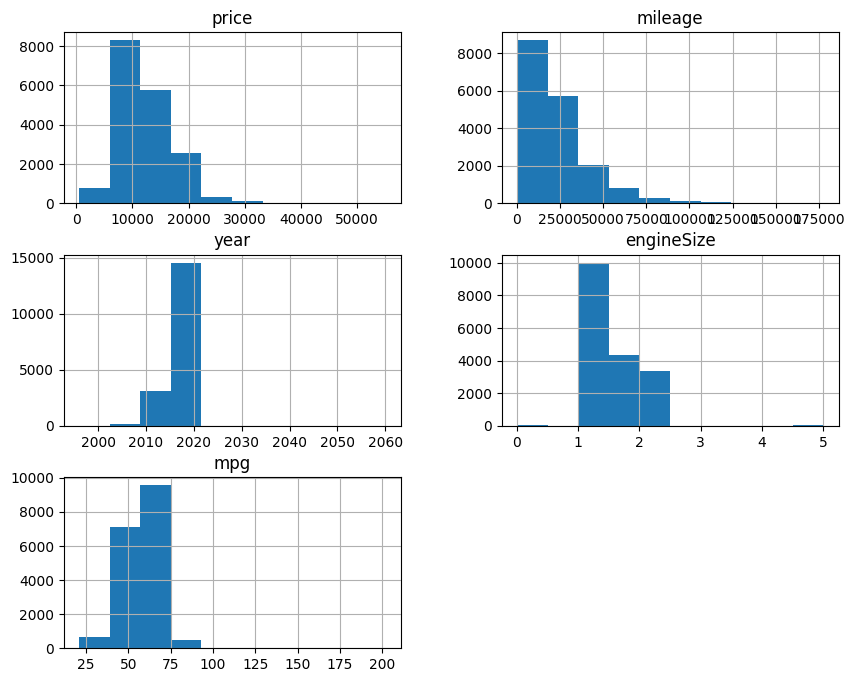

In [13]:
num_cols = ['price', 'mileage', 'year', 'engineSize', 'mpg']
df[num_cols].hist(figsize=(10,8))
plt.show()

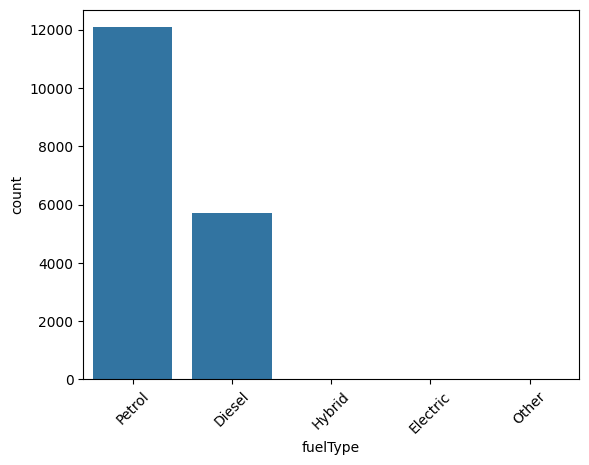

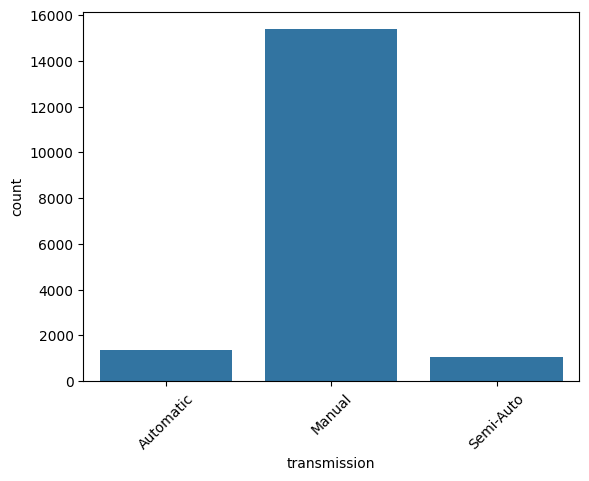

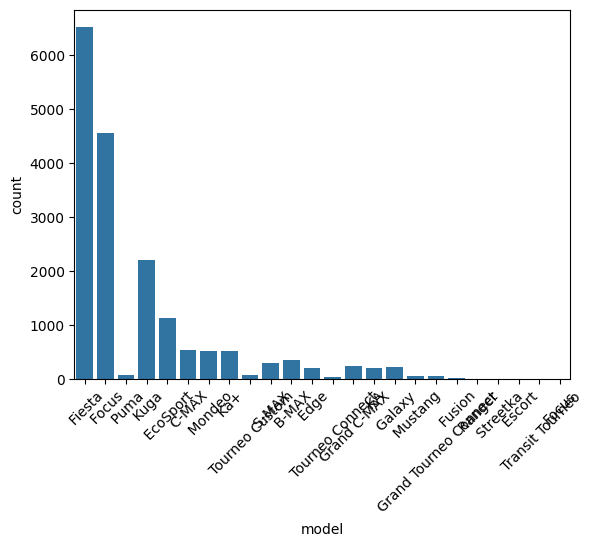

In [15]:
cat_cols = ['fuelType', 'transmission', 'model']
for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.show()

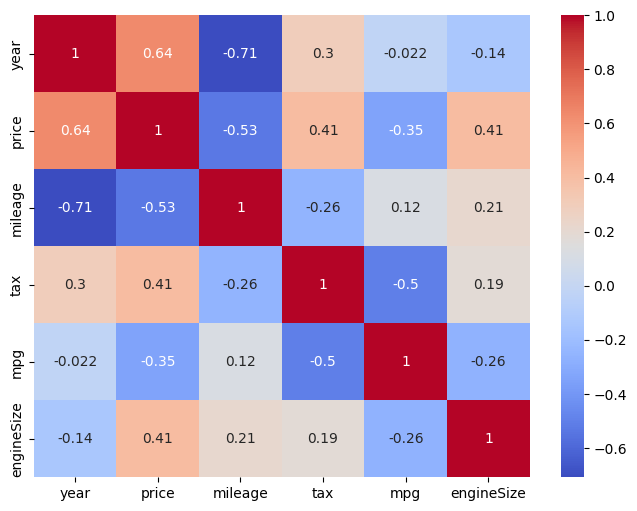

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [19]:
X = df.drop('price', axis=1)
y = df['price']
print("Independent Features:\n", X.columns)
print("Dependent Feature: price")

Independent Features:
 Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='object')
Dependent Feature: price


In [21]:
df_encoded = pd.get_dummies(df, drop_first=True)
df.head()
df_encoded.head()

,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,12000,15944,150,57.7,1.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2018,14000,9083,150,57.7,1.0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,2017,13000,12456,150,57.7,1.0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,2019,17500,10460,145,40.3,1.5,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
4,2019,16500,1482,145,48.7,1.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['year', 'mileage', 'engineSize', 'mpg']
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
df_encoded.head()

,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.067059,12000,-0.382994,150,-0.020597,-0.810561,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,0.554393,14000,-0.736317,150,-0.020597,-0.810561,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0.067059,13000,-0.562616,150,-0.020597,-0.810561,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,1.041726,17500,-0.665405,145,-1.737858,0.345325,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
4,1.041726,16500,-1.127749,145,-0.908836,-0.810561,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


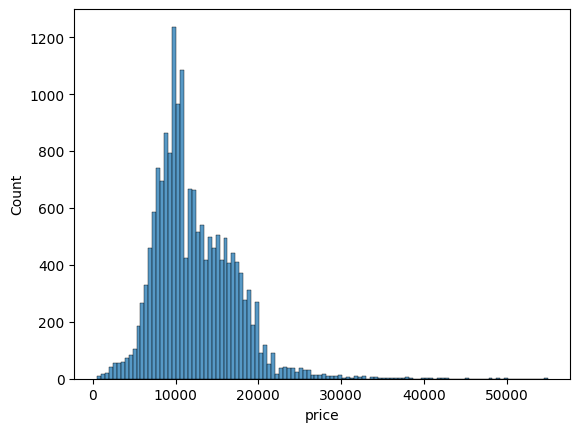

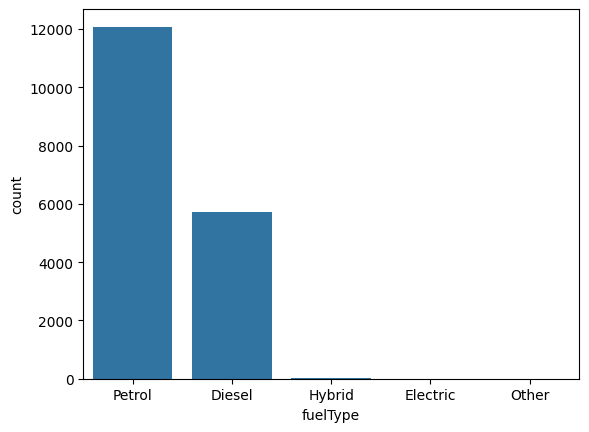

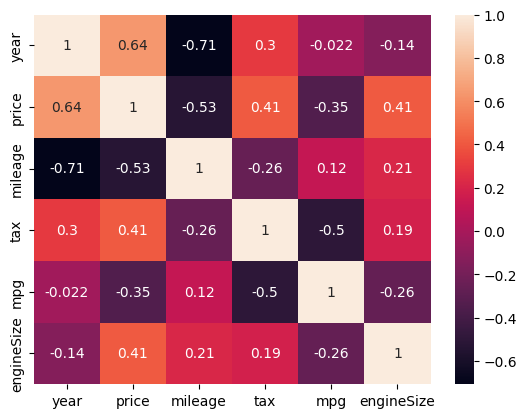

In [26]:
# 1. Load
df = pd.read_csv("/content/ford_car_dataset.csv")
# 2. Clean
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
# 3. EDA
sns.histplot(df['price'])
plt.show()
sns.countplot(x='fuelType', data=df)
plt.show()
sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()
# 4. Features
X = df.drop('price', axis=1)
y = df['price']
# 5. Encoding
X = pd.get_dummies(X, drop_first=True)
# 6. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)